# CELL MESH Demo: HNSC Sample-aware Workflow

This notebook mirrors the HNSC demo workflow but runs `run_cell_mesh()` with `sample_mode="sample_aware"`.

It is intended as a compact test notebook for the sample-aware path:

1. Use `Patient` as `sample_key` and `Celltype (malignancy)` as `cell_type_key`.
2. Filter packaged priors to expressed genes and a small reproducible metabolite subset.
3. Run sample-aware scoring with within-sample permutation.
4. Inspect sample validation, sample-level outputs, cross-sample aggregation, FDR columns, and visual summaries including the directed cell-cell network.


## 1. Imports

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cellmesh
from cellmesh import read_anndata, load_cell_mesh_database, run_cell_mesh
from cellmesh.plotting import (
    plot_significant_event_counts,
    plot_event_dotplot,
    plot_communication_network,
    plot_sample_event_scores,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

print("cellmesh", cellmesh.__version__)
print("cellmesh path:", cellmesh.__file__)


cellmesh 0.4.0
cellmesh path: /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/__init__.py


## 2. Load the Demo h5ad File

The 200-cell HNSC demo file contains a real `Patient` column, which is used here as `sample_key`. Because the dataset is intentionally small, this notebook uses `min_cells=2` as a permissive QC threshold. Every observed `(patient, cell type)` unit is still scored; the threshold only supplies QC flags.

In [2]:
adata_path = PROJECT_ROOT / "cellmesh" / "data" / "demo_HNSC_200cell.h5ad"
adata = read_anndata(adata_path)

cell_type_key = "Celltype (malignancy)"
sample_key = "Patient"

print(adata)
print("cell_type_key:", cell_type_key)
print("sample_key:", sample_key)
display(adata.obs[cell_type_key].value_counts().to_frame("n_cells"))
display(adata.obs[sample_key].value_counts().to_frame("n_cells").head(20))
display(pd.crosstab(adata.obs[sample_key], adata.obs[cell_type_key]))

AnnData object with n_obs × n_vars = 200 × 18241
    obs: 'UMAP_1', 'UMAP_2', 'Celltype (malignancy)', 'celltype', 'Celltype (minor-lineage)', 'Celltype (original)', 'cluster', 'Site', 'Celltype', 'Patient', 'Source', 'Age', 'Gender', 'Stage', 'TNMstage'
cell_type_key: Celltype (malignancy)
sample_key: Patient


,n_cells
Celltype (malignancy),
Malignant cells,84
Stromal cells,68
Immune cells,48


,n_cells
Patient,
HNSCC20,26
HNSCC16,23
HNSCC18,19
HN28,17
HNSCC25,16
HNSCC26,12
HNSCC6,12
HNSCC9,11
HN25,10


Celltype (malignancy),Immune cells,Malignant cells,Stromal cells
Patient,,,
HN23,1,0,0
HN25,1,2,7
HN26,1,6,2
HN28,1,4,12
HNSCC5,1,2,4
HNSCC6,1,8,3
HNSCC8,0,0,2
HNSCC9,9,1,1
HNSCC10,1,0,3


## 3. Load and Filter Packaged Priors

For runtime control, this notebook follows the pooled HNSC demo and selects a small reproducible set of metabolite/HMDB pairs that have both enzyme and sensor evidence in the h5ad gene space.

In [3]:
enzyme_metabolite, metabolite_sensor = load_cell_mesh_database()
genes_present = set(pd.Index(adata.var_names).astype(str))

enzyme_present = enzyme_metabolite[enzyme_metabolite["gene"].astype(str).isin(genes_present)].copy()
sensor_present = metabolite_sensor[metabolite_sensor["sensor_gene"].astype(str).isin(genes_present)].copy()

matched_pairs = sorted(
    set(zip(enzyme_present["metabolite"], enzyme_present["hmdb_id"]))
    .intersection(set(zip(sensor_present["metabolite"], sensor_present["hmdb_id"])))
)

MAX_METABOLITES = 10
selected_pairs = pd.DataFrame(matched_pairs[:MAX_METABOLITES], columns=["metabolite", "hmdb_id"])
enzyme_demo = enzyme_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])
sensor_demo = sensor_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])

print("loaded enzyme prior:", enzyme_metabolite.shape)
print("loaded sensor prior:", metabolite_sensor.shape)
print("enzyme rows with expressed genes:", enzyme_present.shape)
print("sensor rows with expressed genes:", sensor_present.shape)
print("matched metabolite/HMDB pairs:", len(matched_pairs))
print("demo enzyme prior:", enzyme_demo.shape)
print("demo sensor prior:", sensor_demo.shape)
display(selected_pairs)

loaded enzyme prior: (12799, 7)
loaded sensor prior: (9858, 8)
enzyme rows with expressed genes: (11757, 7)
sensor rows with expressed genes: (7746, 8)
matched metabolite/HMDB pairs: 245
demo enzyme prior: (43, 7)
demo sensor prior: (51, 8)


,metabolite,hmdb_id
0,(R)-5-Diphosphomevalonic acid,HMDB0001090
1,11-cis-Retinol,HMDB0006216
2,11beta-Hydroxyprogesterone,HMDB0004031
3,12-HETE,HMDB0006111
4,13-cis-Retinoic acid,HMDB0006219
5,15-HETE,HMDB0003876
6,16a-Hydroxyestrone,HMDB0000335
7,17-Hydroxyprogesterone,HMDB0000374
8,17alpha-Estradiol,HMDB0000429
9,2-Hydroxyestradiol,HMDB0000338


## 4. Run CELL MESH in Sample-aware Mode

`sample_mode="sample_aware"` computes pseudobulks and scores separately for every observed `(sample, cell type)` unit, then aggregates event scores across samples. Within each HMDB ID and P/C/E direction, identical reaction gene sets contribute once and strict subsets are omitted, leaving all inclusion-maximal sets; incomparable overlapping sets remain intact. Within each sample, sender reaction activity is multiplied by `cell_fraction ** sender_abundance_exponent` before positive-reference saturation normalization; the default exponent is `1.0`. `pce_reference="mean"` is the default and uses the strictly-positive arithmetic mean; set it to `"median"` for the robust alternative. The base sender score is `P_score ** 2 / (P_score + C_score)`. Exporter evidence applies the bounded factor `(1-export_weight) + export_weight*E_effective`; with the default `export_weight=0.2`, the factor is in `[0.8, 1.0]`. Missing or gene-unavailable exporter evidence uses fixed `E_effective=0.5`, while measured all-zero exporter capacity uses `0`. Receiver scoring is also a positive-reference saturation score, `R / (R + R_ref)`, calculated independently within each sample. The default `receiver_reference="median"` is the unweighted median across strictly positive observed cell-type means; set it to `"mean"` for the unweighted arithmetic mean. Receiver abundance does not enter the score or reference. Aggregate `cell_mesh_score` equals `event_score_median`, the median of sample-level geometric-mean event scores. The separately aggregated descriptive components are named `metabolite_availability_median`, `sensor_score_median`, and `sensor_expr_frac_median`; their geometric mean is not used as the aggregate event score. Top-level sender and receiver component tables also use across-sample medians. `min_cells` is QC-only and changes none of these values, event coverage, or within-sample permutations. Sample event QC flags are `True`/`False` when the event is computable and nullable `NA` when it is not computable in that sample, for example because an endpoint is unobserved or the metabolite has no production availability. Event visualizations use `qc_only=True` by default.

In [4]:
res = run_cell_mesh(
    adata,
    enzyme_metabolite=enzyme_demo,
    metabolite_sensor=sensor_demo,
    cell_type_key=cell_type_key,
    sample_key=sample_key,
    sample_mode="sample_aware",
    min_cells=2,
    sender_abundance_exponent=1.0,
    pce_reference="mean",
    receiver_reference="median",
    min_expr_frac=0.05,
    allow_self=True,
    n_perms=10,
    random_state=0,
)

print("events:", res.events.shape)
print("sender_scores:", res.sender_scores.shape)
print("receiver_scores:", res.receiver_scores.shape)
print("sample_validation:", res.sample_validation.shape)
print("sample_sender_scores:", res.sample_sender_scores.shape)
print("sample_receiver_scores:", res.sample_receiver_scores.shape)
print("sample_events:", res.sample_events.shape)
print("sample units passing min-cells QC:", int(res.sample_validation["passes_min_cells"].sum()), "/", len(res.sample_validation))
print("availability result keys:", sorted(res.availability_results.keys()))
print("events with permutation p-value:", res.events["perm_pvalue"].notna().sum())
print("events with global FDR:", res.events["fdr_global"].notna().sum())
print("events with sensor-type FDR:", res.events["fdr_sensor_type"].notna().sum())
print("permutation modes:", sorted(res.events["permutation_mode"].dropna().unique()))
print("inference modes:", sorted(res.events["inference_mode"].dropna().unique()))

null_scores = res.events.attrs.get("sample_aware_null_scores")
print("sample-aware null score matrix:", None if null_scores is None else null_scores.shape)

events: (441, 27)
sender_scores: (8, 3)
receiver_scores: (153, 13)
sample_validation: (45, 9)
sample_sender_scores: (108, 3)
sample_receiver_scores: (2295, 11)
sample_events: (8820, 16)
sample units passing min-cells QC: 30 / 45
availability result keys: ['availability_by_sample', 'celltype_qc', 'export_weight', 'receiver_reference', 'sample_events', 'sample_receiver_scores', 'sample_sender_scores', 'sample_validation']
events with permutation p-value: 441
events with global FDR: 441
events with sensor-type FDR: 441
permutation modes: ['within_sample_label_shuffle']
inference modes: ['sample_aware']
sample-aware null score matrix: (441, 10)


## 5. Inspect Sample Cell Counts and Min-cells QC

`sample_validation` reports `n_cells`, `cell_fraction`, and `passes_min_cells` for every observed `(sample, cell type)` unit. Fractions use all cells in that sample as the denominator. Units below `min_cells` still participate in pseudobulks, references, scores, events, and permutations; only their QC flag is `False`. Explicit pass-count columns summarize how many cell types or samples pass the threshold. A blank heatmap position is a structurally unobserved combination, whereas a red-outlined observed position failed the QC threshold.

,sample,cell_type,n_cells,cell_fraction,passes_min_cells,n_celltypes_passing_min_cells_in_sample,n_samples_passing_min_cells_for_celltype,n_observed_celltypes_in_sample,n_samples_observed_for_celltype
0,HN23,Immune cells,1,1.000000,False,0,6,1,14
1,HN25,Immune cells,1,0.100000,False,2,6,3,14
2,HN25,Malignant cells,2,0.200000,True,2,11,3,15
3,HN25,Stromal cells,7,0.700000,True,2,13,3,16
4,HN26,Immune cells,1,0.111111,False,2,6,3,14
5,HN26,Malignant cells,6,0.666667,True,2,11,3,15
6,HN26,Stromal cells,2,0.222222,True,2,13,3,16
7,HN28,Immune cells,1,0.058824,False,2,6,3,14
8,HN28,Malignant cells,4,0.235294,True,2,11,3,15
9,HN28,Stromal cells,12,0.705882,True,2,13,3,16


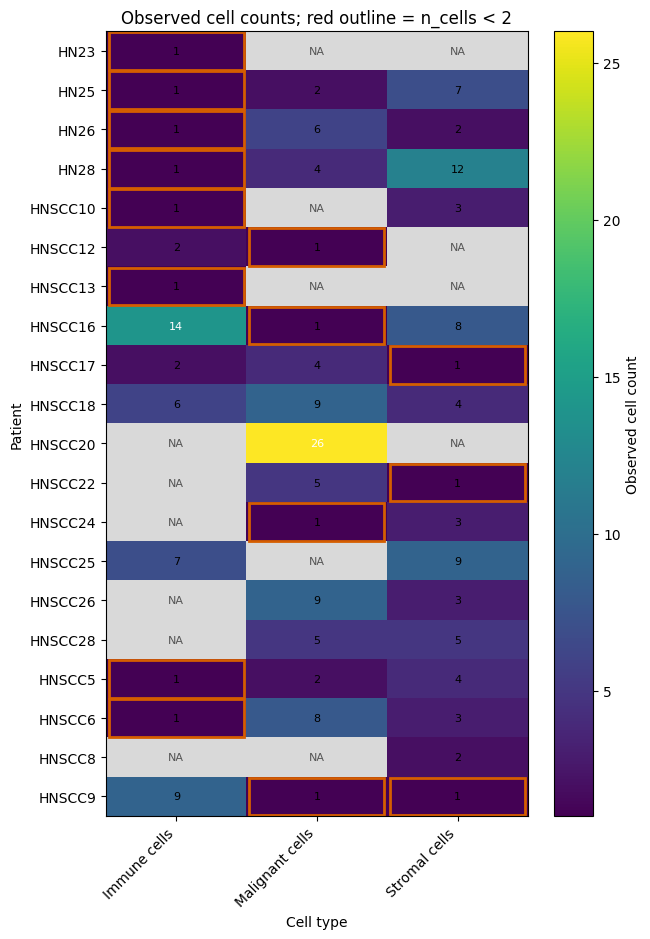

In [5]:
validation = res.sample_validation.copy()
display(validation.sort_values(["sample", "cell_type"]).head(30))

count_matrix = validation.pivot(index="sample", columns="cell_type", values="n_cells").astype(float)
passes_matrix = validation.pivot(index="sample", columns="cell_type", values="passes_min_cells")

fig, ax = plt.subplots(figsize=(1.2 * count_matrix.shape[1] + 3, 0.35 * count_matrix.shape[0] + 2.5))
count_values = np.ma.masked_invalid(count_matrix.to_numpy(dtype=float))
count_cmap = plt.get_cmap("viridis").copy()
count_cmap.set_bad("#d9d9d9")
image = ax.imshow(count_values, cmap=count_cmap, aspect="auto")
ax.set_xticks(np.arange(count_matrix.shape[1]))
ax.set_xticklabels(count_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(count_matrix.shape[0]))
ax.set_yticklabels(count_matrix.index)
ax.set_xlabel("Cell type")
ax.set_ylabel("Patient")
ax.set_title(f"Observed cell counts; red outline = n_cells < {res.parameters['min_cells']}")
for i, sample in enumerate(count_matrix.index):
    for j, cell_type in enumerate(count_matrix.columns):
        value = count_matrix.loc[sample, cell_type]
        if pd.isna(value):
            ax.text(j, i, "NA", ha="center", va="center", fontsize=8, color="#555555")
            continue
        text_color = "white" if image.norm(value) > 0.45 else "black"
        ax.text(j, i, str(int(value)), ha="center", va="center", fontsize=8, color=text_color)
        if not bool(passes_matrix.loc[sample, cell_type]):
            ax.add_patch(plt.Rectangle((j - 0.48, i - 0.48), 0.96, 0.96, fill=False, edgecolor="#D55E00", linewidth=2.0))
fig.colorbar(image, ax=ax, label="Observed cell count")
assert validation["n_cells"].gt(0).all()
assert {"n_celltypes_passing_min_cells_in_sample", "n_samples_passing_min_cells_for_celltype"}.issubset(validation.columns)
plt.tight_layout()
plt.show()

## 6. Inspect Top Sample-aware Events

In [6]:
event_cols = [
    "sender",
    "receiver",
    "metabolite",
    "hmdb_id",
    "sensor_gene",
    "sensor_type",
    "metabolite_availability_median",
    "sensor_score_median",
    "sensor_expr_frac_median",
    "cell_mesh_score",
    "event_score_median",
    "event_score_iqr",
    "n_samples_coobserved",
    "n_samples_positive",
    "event_prevalence",
    "n_samples_passing_min_cells",
    "min_cells_pass_prevalence",
    "sender_passes_min_cells",
    "receiver_passes_min_cells",
    "passes_min_cells",
    "perm_pvalue",
    "fdr_global",
    "fdr_sensor_type",
    "permutation_mode",
    "inference_mode",
]

display(res.events[event_cols].head(25))

coverage_summary = (
    res.events.groupby("n_samples_coobserved")
    .size()
    .rename("n_events")
    .reset_index()
    .sort_values("n_samples_coobserved")
)
display(coverage_summary)

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,metabolite_availability_median,sensor_score_median,sensor_expr_frac_median,cell_mesh_score,event_score_median,event_score_iqr,n_samples_coobserved,n_samples_positive,event_prevalence,n_samples_passing_min_cells,min_cells_pass_prevalence,sender_passes_min_cells,receiver_passes_min_cells,passes_min_cells,perm_pvalue,fdr_global,fdr_sensor_type,permutation_mode,inference_mode
0,Malignant cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,PPARD,Other receptor,0.450000,0.623370,0.733333,0.480007,0.480007,0.486263,12,9,0.750000,11,0.916667,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
1,Stromal cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,PPARD,Other receptor,0.416034,0.629374,0.800000,0.474342,0.474342,0.545099,11,7,0.636364,8,0.727273,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
2,Malignant cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,RXRA,Other receptor,0.450000,0.500000,0.291667,0.474342,0.474342,0.455231,12,9,0.750000,11,0.916667,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
3,Malignant cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,VDR,Other receptor,0.450000,0.500000,0.450000,0.474342,0.474342,0.541230,12,8,0.666667,11,0.916667,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
4,Malignant cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,Other receptor,0.450000,0.500000,0.111111,0.474342,0.474342,NaN,1,1,1.000000,1,1.000000,True,True,True,0.181818,1.0,1.0,within_sample_label_shuffle,sample_aware
5,Malignant cells,Malignant cells,12-HETE,HMDB0006111,LTB4R2,Cell surface receptor,0.450000,0.500000,0.250000,0.474342,0.474342,0.370257,15,11,0.733333,11,0.733333,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
6,Malignant cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,RARG,Other receptor,0.450000,0.500000,0.500000,0.474342,0.474342,0.440141,12,9,0.750000,11,0.916667,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
7,Malignant cells,Malignant cells,15-HETE,HMDB0003876,LTB4R2,Cell surface receptor,0.446191,0.500000,0.291667,0.463159,0.463159,0.227209,14,11,0.785714,11,0.785714,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
8,Malignant cells,Malignant cells,17-Hydroxyprogesterone,HMDB0000374,NR2C1,Other receptor,0.450000,0.461888,0.480769,0.444590,0.444590,0.447074,12,9,0.750000,11,0.916667,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware
9,Stromal cells,Malignant cells,15-HETE,HMDB0003876,LTB4R2,Cell surface receptor,0.479065,0.500000,0.333333,0.443015,0.443015,0.502773,13,9,0.692308,8,0.615385,True,True,True,0.090909,1.0,1.0,within_sample_label_shuffle,sample_aware


,n_samples_coobserved,n_events
0,1,5
1,2,4
2,7,78
3,8,142
4,9,16
5,10,16
6,11,75
7,12,84
8,13,13
9,14,2


## 7. Sample-level Scores for One Event

`plot_sample_event_scores` uses `qc_only=True` by default, so the first plot shows only sample rows where both observed endpoints pass min-cells QC. This is a display filter only. The second call uses `qc_only=False` to show every sample row: low-count computable events retain their calculated scores, while `NA` means that the event is not computable in that sample (for example, an endpoint is unobserved or the metabolite has no production availability). The all-row dashed median matches the aggregate `event_score_median`; the QC-only median describes only the displayed passing subset.

target event key: ('Stromal cells', 'Stromal cells', '(R)-5-Diphosphomevalonic acid', 'HMDB0001090', 'PMVK', 'Other receptor')


,value
sender,Stromal cells
receiver,Stromal cells
metabolite,(R)-5-Diphosphomevalonic acid
hmdb_id,HMDB0001090
sensor_gene,PMVK
sensor_type,Other receptor
metabolite_availability_median,0.064789
sensor_score_median,0.025857
sensor_expr_frac_median,0.083333
cell_mesh_score,0.04093


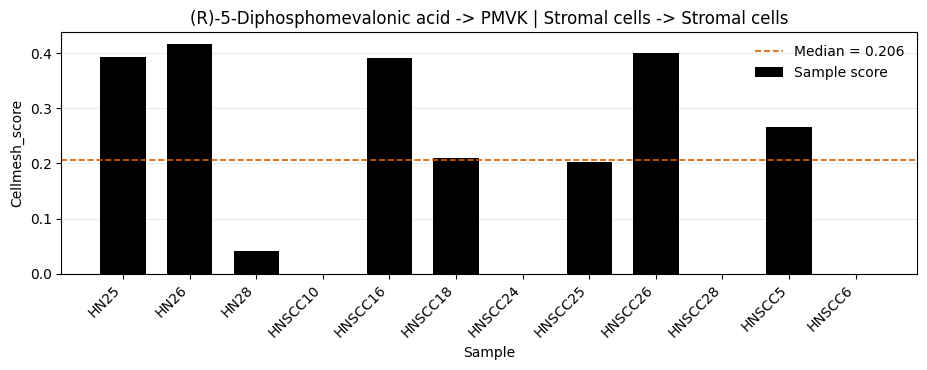

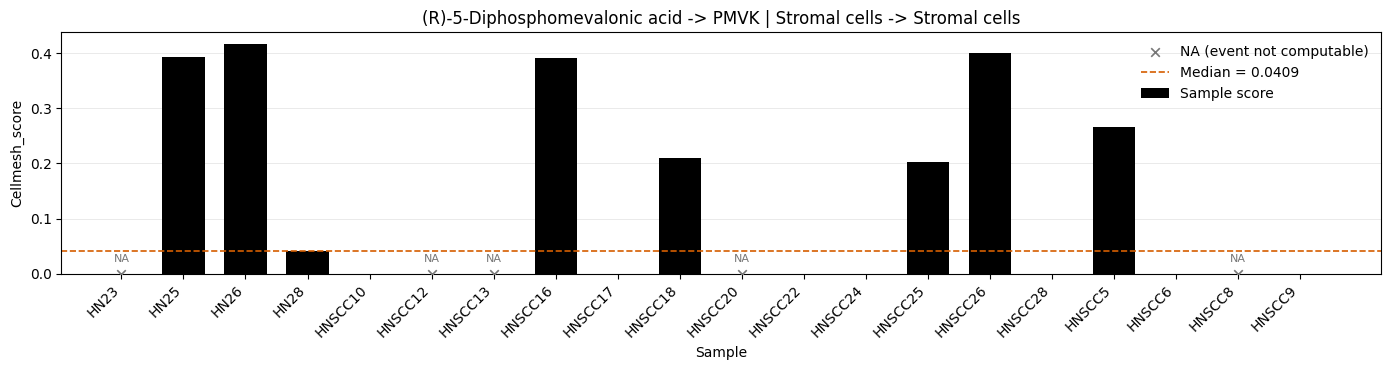

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,sample,metabolite_availability,sensor_score,sensor_expr_frac,sender_n_cells,receiver_n_cells,sender_passes_min_cells,receiver_passes_min_cells,passes_min_cells,cell_mesh_score
0,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN25,0.303732,0.509882,0.285714,7.0,7.0,True,True,True,0.393532
1,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN26,0.246155,0.706534,0.500000,2.0,2.0,True,True,True,0.417034
2,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN28,0.064789,0.025857,0.083333,12.0,12.0,True,True,True,0.040930
3,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC10,0.000000,0.000000,0.000000,3.0,3.0,True,True,True,0.000000
4,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC16,0.377642,0.405422,0.250000,8.0,8.0,True,True,True,0.391286
5,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC18,0.171966,0.255978,0.250000,4.0,4.0,True,True,True,0.209808
6,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC24,0.000000,0.000000,0.000000,3.0,3.0,True,True,True,0.000000
7,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC25,0.132053,0.312147,0.111111,9.0,9.0,True,True,True,0.203027
8,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC26,0.313475,0.510983,0.333333,3.0,3.0,True,True,True,0.400225
9,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC28,0.000000,0.000000,0.000000,5.0,5.0,True,True,True,0.000000


,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,sample,metabolite_availability,sensor_score,sensor_expr_frac,sender_n_cells,receiver_n_cells,sender_passes_min_cells,receiver_passes_min_cells,passes_min_cells,cell_mesh_score
0,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN23,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN
1,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN25,0.303732,0.509882,0.285714,7.0,7.0,True,True,True,0.393532
2,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN26,0.246155,0.706534,0.500000,2.0,2.0,True,True,True,0.417034
3,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HN28,0.064789,0.025857,0.083333,12.0,12.0,True,True,True,0.040930
4,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC10,0.000000,0.000000,0.000000,3.0,3.0,True,True,True,0.000000
5,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC12,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN
6,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC13,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN
7,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC16,0.377642,0.405422,0.250000,8.0,8.0,True,True,True,0.391286
8,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC17,0.000000,0.000000,0.000000,1.0,1.0,False,False,False,0.000000
9,Stromal cells,Stromal cells,(R)-5-Diphosphomevalonic acid,HMDB0001090,PMVK,Other receptor,HNSCC18,0.171966,0.255978,0.250000,4.0,4.0,True,True,True,0.209808


QC-only summary: {'qc_only': True, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': True, 'events_before_qc': 20, 'events_passing_qc': 12, 'events_failing_qc': 8, 'events_after_qc': 12, 'events_excluded_by_qc': 8}
all-row summary: {'qc_only': False, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': False, 'events_before_qc': 20, 'events_passing_qc': 12, 'events_failing_qc': 8, 'events_after_qc': 20, 'events_excluded_by_qc': 0}
samples without a computable event score: ['HN23', 'HNSCC12', 'HNSCC13', 'HNSCC20', 'HNSCC8']


In [7]:
from cellmesh.plotting import plot_sample_event_scores

assert not res.events.empty

positive_events = res.events.loc[
    (res.events["cell_mesh_score"] > 0)
    & (res.events["n_samples_positive"] > 0)
    & res.events["passes_min_cells"].eq(True)
].copy()
assert not positive_events.empty, "No event with a positive sample-level score is available"

target_event = positive_events.sort_values(
    ["n_samples_passing_min_cells", "min_cells_pass_prevalence", "n_samples_positive", "cell_mesh_score"],
    ascending=[False, False, False, False],
    na_position="last",
).iloc[0]
event_key_cols = ["sender", "receiver", "metabolite", "hmdb_id", "sensor_gene", "sensor_type"]
target_key = tuple(target_event[col] for col in event_key_cols)

print("target event key:", target_key)
display(target_event[event_cols].to_frame("value"))

sample_event_plot = plot_sample_event_scores(
    res,
    sender=target_event["sender"],
    receiver=target_event["receiver"],
    metabolite=target_event["metabolite"],
    hmdb_id=target_event["hmdb_id"],
    sensor_gene=target_event["sensor_gene"],
    sensor_type=target_event["sensor_type"],
    qc_only=True,
)
plt.show()

sample_event_all = plot_sample_event_scores(
    res,
    sender=target_event["sender"],
    receiver=target_event["receiver"],
    metabolite=target_event["metabolite"],
    hmdb_id=target_event["hmdb_id"],
    sensor_gene=target_event["sensor_gene"],
    sensor_type=target_event["sensor_type"],
    qc_only=False,
)
plt.show()

display(sample_event_plot["sample_scores"])
display(sample_event_all["sample_scores"])
print("QC-only summary:", sample_event_plot["qc"])
print("all-row summary:", sample_event_all["qc"])
print("samples without a computable event score:", sample_event_all["missing_samples"])

assert tuple(sample_event_plot["event_key"][col] for col in event_key_cols) == target_key
assert sample_event_plot["qc"]["qc_only"] is True
assert sample_event_all["qc"]["qc_only"] is False
assert sample_event_plot["sample_scores"]["passes_min_cells"].eq(True).all()
assert sample_event_all["n_samples_coobserved"] == int(target_event["n_samples_coobserved"])
assert np.isclose(sample_event_all["median_score"], target_event["event_score_median"])
assert sample_event_all["sample_scores"]["sample"].nunique() == res.sample_events["sample"].nunique()
assert sample_event_plot["median_score"] > 0
assert sample_event_plot["qc"]["events_after_qc"] == len(sample_event_plot["sample_scores"])
assert (sample_event_all["sample_scores"]["cell_mesh_score"] > 0).sum() == int(target_event["n_samples_positive"])
all_missing_rows = sample_event_all["sample_scores"].loc[lambda df: df["cell_mesh_score"].isna()]
missing_qc_cols = ["sender_passes_min_cells", "receiver_passes_min_cells", "passes_min_cells"]
assert len(all_missing_rows) == len(sample_event_all["missing_samples"])
assert all_missing_rows[missing_qc_cols].isna().all().all()

## 8. Global Overview: Event Counts After Thresholding

This reuses the standard global event count plot with `max_fdr=0.8` and its default `qc_only=True`, so min-cells-QC display filtering happens before the FDR threshold. Set `qc_only=False` to show all calculated aggregate events. Because this fast demo uses only `n_perms=10`, all adjusted FDR values may remain above that threshold; in that case the all-zero heatmap is the expected filtered result. The overview-specific variable names keep these settings from leaking into later exploratory plots.

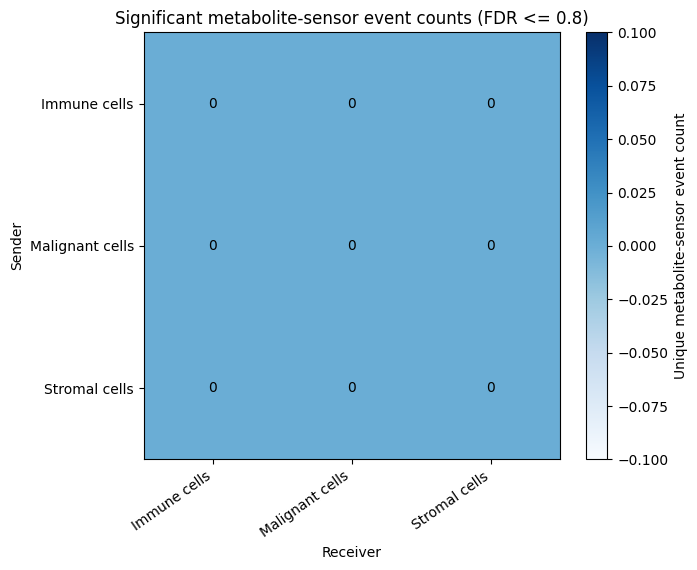

{'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': 0.8, 'fdr_col': 'fdr_sensor_type', 'events_before_filter': 441, 'events_after_filter': 0, 'unique_events_after_filter': 0, 'qc_only': True, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': True, 'events_before_qc': 441, 'events_passing_qc': 441, 'events_failing_qc': 0, 'events_after_qc': 441, 'events_excluded_by_qc': 0}
{'qc_only': True, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': True, 'events_before_qc': 441, 'events_passing_qc': 441, 'events_failing_qc': 0, 'events_after_qc': 441, 'events_excluded_by_qc': 0}


,sender,receiver,metabolite_sensor_count


In [8]:
from cellmesh.plotting import plot_significant_event_counts

overview_min_cell_mesh_score = None
overview_max_perm_pvalue = None
overview_max_fdr = 0.8
overview_qc_only = True

sig_overview = plot_significant_event_counts(
    res,
    min_cell_mesh_score=overview_min_cell_mesh_score,
    max_perm_pvalue=overview_max_perm_pvalue,
    max_fdr=overview_max_fdr,
    qc_only=overview_qc_only,
)
plt.show()

print(sig_overview["thresholds"])
print(sig_overview["qc"])
display(sig_overview["summary"])
assert sig_overview["thresholds"]["max_fdr"] == 0.8
assert sig_overview["qc"]["qc_only"] is True

## 9. Directed Cell-Cell Communication Network

This directed circular network aggregates min-cells-QC-passing communication events by sender-receiver cell-type pair because `qc_only=True`. This is a display filter only. Edge width represents the number of unique communication events, edge color represents the summed Cellmesh_score, and node area represents the number of distinct connected cell types. Because `n_perms=10` gives insufficient FDR resolution for this demo, this exploratory network uses its own variables and does not apply an FDR filter. The displayed edge and node tables expose the exact aggregates and visual values used in the figure.


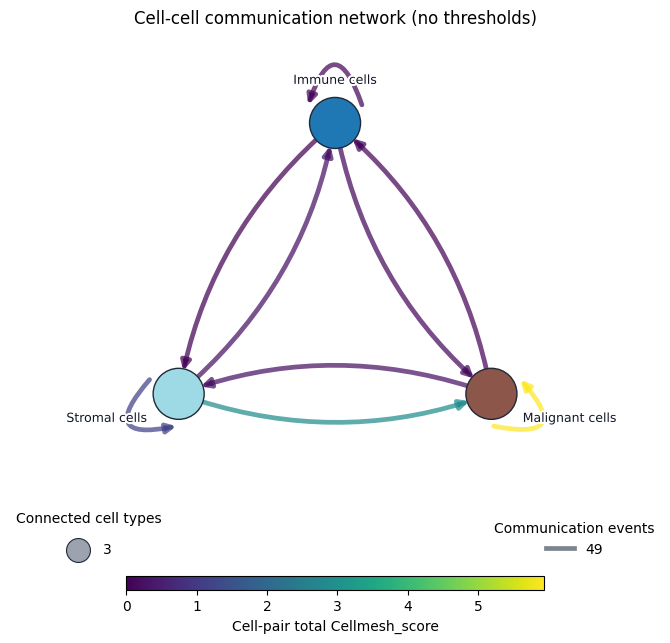

,sender,receiver,event_count,total_score,mean_score,edge_width
4,Malignant cells,Malignant cells,49,5.938423,0.121192,3.4
7,Stromal cells,Malignant cells,49,2.867506,0.058521,3.4
8,Stromal cells,Stromal cells,49,1.177117,0.024023,3.4
5,Malignant cells,Stromal cells,49,0.261855,0.005344,3.4
6,Stromal cells,Immune cells,49,0.257426,0.005254,3.4
1,Immune cells,Malignant cells,49,0.125032,0.002552,3.4
0,Immune cells,Immune cells,49,0.089373,0.001824,3.4
3,Malignant cells,Immune cells,49,0.063465,0.001295,3.4
2,Immune cells,Stromal cells,49,0.000000,0.000000,3.4


,cell_type,connected_cell_type_count,event_count,total_score,node_size
0,Immune cells,3,245,0.535296,1350.0
1,Malignant cells,3,245,9.256281,1350.0
2,Stromal cells,3,245,4.563904,1350.0


In [9]:
from cellmesh.plotting import plot_communication_network

network_min_cell_mesh_score = None
network_max_perm_pvalue = None
network_max_fdr = None
network_qc_only = True

communication_network = plot_communication_network(
    res,
    min_cell_mesh_score=network_min_cell_mesh_score,
    max_perm_pvalue=network_max_perm_pvalue,
    max_fdr=network_max_fdr,
    qc_only=network_qc_only,
)

edge_table = communication_network["edge_table"]
node_table = communication_network["node_table"]

# Smoke checks also document the returned plotting contract.
assert not edge_table.empty
assert (edge_table["event_count"] >= 1).all()
assert len(communication_network["edge_artists"]) == len(edge_table)
assert set(node_table["cell_type"]) == set(edge_table["sender"]) | set(edge_table["receiver"])
assert edge_table.sort_values("event_count")["edge_width"].is_monotonic_increasing
assert communication_network["qc"]["qc_only"] is True

plt.show()

display(
    edge_table[
        ["sender", "receiver", "event_count", "total_score", "mean_score", "edge_width"]
    ]
    .sort_values(["event_count", "total_score"], ascending=False)
    .head(20)
)
display(
    node_table[
        ["cell_type", "connected_cell_type_count", "event_count", "total_score", "node_size"]
    ].sort_values(["connected_cell_type_count", "event_count"], ascending=False)
)


## 10. Dotplot: Top Sample-aware Communication Events

Rows are metabolite-sensor events (`metabolite -> sensor_gene`), columns are receiver cell types within sender-specific panels, color encodes `Cellmesh_score`, and bubble size represents FDR on the existing `-log10(FDR)` size scale. The default `qc_only=True` displays only aggregate events with at least one co-observed sample where both endpoints pass min-cells QC; set it to `False` to include all calculated events.


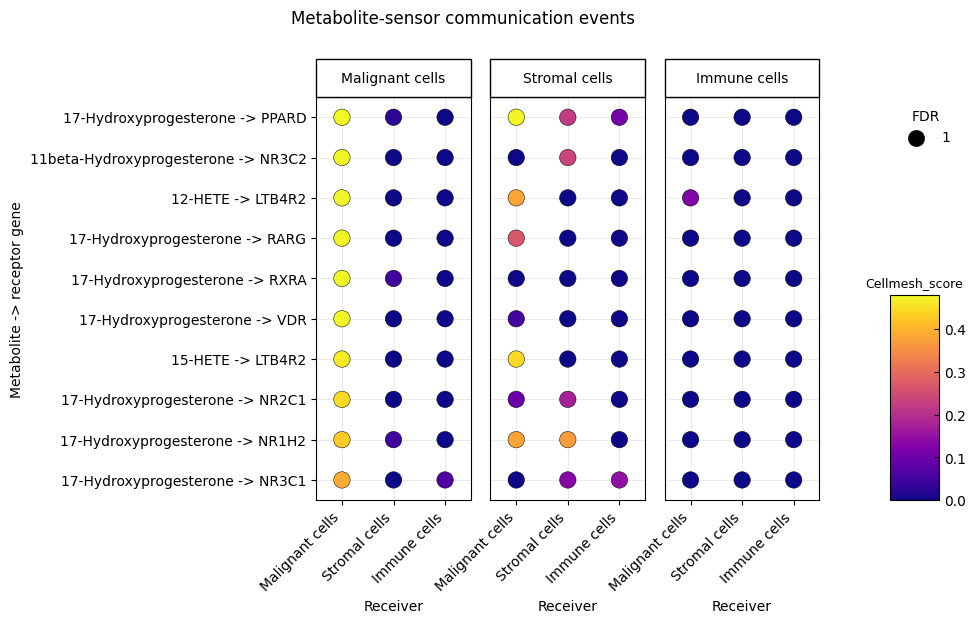

{'top_n': 10, 'event_keys': None, 'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': None, 'events_before_filter': 441, 'events_after_filter': 441, 'events_plotted': 90, 'qc_only': True, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': True, 'events_before_qc': 441, 'events_passing_qc': 441, 'events_failing_qc': 0, 'events_after_qc': 441, 'events_excluded_by_qc': 0}
{'qc_only': True, 'qc_column': 'passes_min_cells', 'qc_column_present': True, 'qc_applied': True, 'events_before_qc': 441, 'events_passing_qc': 441, 'events_failing_qc': 0, 'events_after_qc': 441, 'events_excluded_by_qc': 0}


,sender,receiver,metabolite,hmdb_id,sensor_gene,cell_mesh_score,perm_pvalue,fdr_sensor_type
43,Immune cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
185,Immune cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
119,Immune cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
166,Malignant cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
4,Malignant cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.474342,0.181818,1.0
263,Malignant cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
298,Stromal cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
348,Stromal cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
20,Stromal cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.237171,0.272727,1.0
44,Immune cells,Immune cells,12-HETE,HMDB0006111,LTB4R2,0.000000,1.000000,1.0


In [10]:
from cellmesh.plotting import plot_event_dotplot

event_dotplot_top = plot_event_dotplot(
    res,
    top_n=10,
    event_keys=None,
    max_fdr=None,
    qc_only=True,
)
plt.show()

print(event_dotplot_top["thresholds"])
print(event_dotplot_top["qc"])
display(
    event_dotplot_top["plot_events"][
        [
            "sender",
            "receiver",
            "metabolite",
            "hmdb_id",
            "sensor_gene",
            "cell_mesh_score",
            "perm_pvalue",
            "fdr_sensor_type",
        ]
    ].head(30)
)

## 11. Sample-aware Output Checks

These lightweight assertions are meant to make the notebook useful as a smoke test for the sample-aware API.


In [11]:
required_event_columns = {
    "metabolite_availability_median",
    "sensor_score_median",
    "sensor_expr_frac_median",
    "event_score_median",
    "event_score_iqr",
    "n_samples_coobserved",
    "n_samples_positive",
    "event_prevalence",
    "n_samples_passing_min_cells",
    "min_cells_pass_prevalence",
    "sender_passes_min_cells",
    "receiver_passes_min_cells",
    "passes_min_cells",
    "perm_pvalue",
    "fdr_global",
    "fdr_sensor_type",
    "permutation_mode",
    "inference_mode",
}
missing = required_event_columns.difference(res.events.columns)
assert not missing, missing
assert set(res.events["inference_mode"].dropna()) == {"sample_aware"}
assert set(res.events["permutation_mode"].dropna()) == {"within_sample_label_shuffle"}
assert res.sample_validation is not None and not res.sample_validation.empty
assert res.sample_sender_scores is not None
assert res.sample_receiver_scores is not None
assert res.sample_events is not None
assert {"passes_min_cells", "n_observed_celltypes_in_sample", "n_samples_observed_for_celltype", "n_celltypes_passing_min_cells_in_sample", "n_samples_passing_min_cells_for_celltype"}.issubset(res.sample_validation.columns)
assert {"sender_passes_min_cells", "receiver_passes_min_cells", "passes_min_cells"}.issubset(res.sample_events.columns)
assert res.parameters["receiver_reference"] == "median"
assert res.parameters["receiver_formula"] == "R/(R+R_ref)"
assert res.parameters["sample_aware_component_aggregation"] == "median"
assert res.parameters["sample_aware_event_score"] == "median_of_sample_level_cell_mesh_scores"
assert np.allclose(res.events["cell_mesh_score"], res.events["event_score_median"])
assert res.availability_results["receiver_reference"] == "median"
assert null_scores is not None and null_scores.shape[1] == 10
assert sample_event_plot["n_samples_coobserved"] > 0
assert sample_event_plot["median_score"] > 0
assert sample_event_all["sample_scores"]["cell_mesh_score"].isna().sum() == len(sample_event_all["missing_samples"])
structural_missing = res.sample_events["cell_mesh_score"].isna()
assert res.sample_events.loc[structural_missing, ["sender_passes_min_cells", "receiver_passes_min_cells", "passes_min_cells"]].isna().all().all()
assert res.sample_events.loc[~structural_missing, ["sender_passes_min_cells", "receiver_passes_min_cells", "passes_min_cells"]].notna().all().all()
reported_qc = res.events.set_index(event_key_cols)["passes_min_cells"].sort_index()
expected_qc = res.sample_events.groupby(event_key_cols)["passes_min_cells"].apply(lambda values: values.eq(True).any()).sort_index()
pd.testing.assert_series_equal(reported_qc.astype(bool), expected_qc.astype(bool), check_names=False)
assert np.allclose(res.events["min_cells_pass_prevalence"], res.events["n_samples_passing_min_cells"] / res.events["n_samples_coobserved"])

print("sample-aware smoke checks passed")

sample-aware smoke checks passed
